In [12]:
import os
os.listdir()

['.ipynb_checkpoints', 'desktop.ini', 'phân tích data.ipynb', 'sales_data.csv']

In [13]:
import pandas as pd 
df = pd.read_csv('sales_data.csv')

In [14]:
df.head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


In [46]:
# kiểm tra null
df.isnull().sum().reset_index()

,index,0
0,Date,0
1,Day,0
2,Month,0
3,Year,0
4,Customer_Age,0
5,Age_Group,0
6,Customer_Gender,0
7,Country,0
8,State,0
9,Product_Category,0


In [20]:
#chuyển Date sang datetime
df['Date'] = pd.to_datetime(df['Date'])

In [48]:
# kiểm tra duplicate
df.duplicated().sum()

np.int64(1000)

In [23]:
df[df.duplicated()]

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
1021,2013-12-19,19,December,2013,22,Youth (<25),M,Australia,New South Wales,Accessories,Bike Stands,All-Purpose Bike Stand,9,59,159,714,531,1245
1091,2015-09-30,30,September,2015,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,5,4,10,20,20,40
1093,2013-10-24,24,October,2013,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,2,4,10,8,8,16
1095,2015-10-24,24,October,2015,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,1,4,10,4,4,8
1193,2016-01-15,15,January,2016,42,Adults (35-64),M,France,Seine Saint Denis,Accessories,Bottles and Cages,Water Bottle - 30 oz.,14,2,5,29,28,57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111029,2014-02-18,18,February,2014,49,Adults (35-64),F,United States,California,Bikes,Touring Bikes,"Touring-1000 Blue, 60",1,1482,2384,854,1482,2336
111031,2016-02-18,18,February,2016,49,Adults (35-64),F,United States,California,Bikes,Touring Bikes,"Touring-1000 Blue, 60",1,1482,2384,854,1482,2336
111265,2014-04-27,27,April,2014,31,Young Adults (25-34),M,United States,Washington,Bikes,Touring Bikes,"Touring-1000 Blue, 50",1,1482,2384,378,1482,1860
111953,2013-09-20,20,September,2013,42,Adults (35-64),M,Canada,British Columbia,Bikes,Touring Bikes,"Touring-3000 Yellow, 44",1,461,742,274,461,735


In [22]:
# thống kê
df.describe()

,Date,Day,Year,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
count,113036,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000
mean,2014-11-23 12:14:55.063519232,15.665753,2014.401739,35.919212,11.901660,267.296366,452.938427,285.051665,469.318695,754.370360
min,2011-01-01 00:00:00,1.000000,2011.000000,17.000000,1.000000,1.000000,2.000000,-30.000000,1.000000,2.000000
25%,2013-12-22 00:00:00,8.000000,2013.000000,28.000000,2.000000,2.000000,5.000000,29.000000,28.000000,63.000000
50%,2014-06-27 00:00:00,16.000000,2014.000000,35.000000,10.000000,9.000000,24.000000,101.000000,108.000000,223.000000
75%,2016-01-09 00:00:00,23.000000,2016.000000,43.000000,20.000000,42.000000,70.000000,358.000000,432.000000,800.000000
max,2016-07-31 00:00:00,31.000000,2016.000000,87.000000,32.000000,2171.000000,3578.000000,15096.000000,42978.000000,58074.000000
std,NaN,8.781567,1.272510,11.021936,9.561857,549.835483,922.071219,453.887443,884.866118,1309.094674


In [24]:
df['YearMonth'] = df['Date'].dt.to_period('M')

In [49]:
 
df['Profit_Margin'] = df['Profit'] / df['Revenue']

In [41]:
#sale theo năm
df.groupby('YearMonth')['Revenue'].sum().reset_index()

,YearMonth,Revenue
0,2011-01,675193
1,2011-02,637598
2,2011-03,708517
3,2011-04,698782
4,2011-05,734537
...,...,...
57,2016-03,2608663
58,2016-04,2756864
59,2016-05,3264343
60,2016-06,3586300


In [33]:
#sale theo Country
df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).reset_index()

,Country,Revenue
0,United States,27975547
1,Australia,21302059
2,United Kingdom,10646196
3,Germany,8978596
4,France,8432872
5,Canada,7935738


In [42]:
#Country bán lời nhất
df.groupby('Country')['Profit_Margin'].mean().sort_values(ascending=False).reset_index()

,Country,Profit_Margin
0,Canada,0.548469
1,United Kingdom,0.500285
2,United States,0.481706
3,Germany,0.460083
4,France,0.436901
5,Australia,0.418813


In [44]:
# Top 10 sản phẩm doanh thu nhiều
df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()


,Product,Revenue
0,"Road-150 Red, 62",3829416
1,"Mountain-200 Black, 38",3366248
2,"Road-150 Red, 52",3180840
3,"Road-150 Red, 56",3158805
4,"Mountain-200 Silver, 42",3081078
5,"Mountain-200 Silver, 38",3035442
6,"Road-150 Red, 48",2965309
7,"Mountain-200 Black, 46",2769620
8,"Mountain-200 Black, 42",2641606
9,"Mountain-200 Silver, 46",2376146


In [45]:
#Sản phẩm hàng đầu theo tỷ suất lợi nhuận
df.groupby('Product')['Profit_Margin'].mean().sort_values(ascending=False).head(10).reset_index()

,Product,Profit_Margin
0,Road Tire Tube,0.722138
1,"Racing Socks, L",0.630829
2,"Racing Socks, M",0.629262
3,Road Bottle Cage,0.625271
4,ML Road Tire,0.597989
5,Fender Set - Mountain,0.597491
6,HL Mountain Tire,0.594565
7,ML Mountain Tire,0.594333
8,LL Mountain Tire,0.593818
9,"Women's Mountain Shorts, S",0.592369


In [36]:
#lợi nhuận theo danh mục
df.groupby('Product_Category')['Profit'].sum().reset_index()

,Product_Category,Profit
0,Accessories,8862377
1,Bikes,20519276
2,Clothing,2839447


In [37]:
#phân tích độ tuổi khách hàng
df.groupby('Age_Group')['Revenue'].sum().reset_index()

,Age_Group,Revenue
0,Adults (35-64),42584153
1,Seniors (64+),308042
2,Young Adults (25-34),30655614
3,Youth (<25),11723199


In [55]:
#đếm số lượng khách hàng theo nhóm tuổi
df['Age_Group'].value_counts().reset_index()

,Age_Group,count
0,Adults (35-64),55824
1,Young Adults (25-34),38654
2,Youth (<25),17828
3,Seniors (64+),730


In [51]:
pd.pivot_table(df, values='Revenue', index='Country', columns='Product_Category', aggfunc='sum')

Product_Category,Accessories,Bikes,Clothing
Country,,,
Australia,2746405,16952818,1602836
Canada,2282940,4275003,1377795
France,1388053,6324125,720694
Germany,1548818,6792782,636996
United Kingdom,1873023,7856994,916179
United States,5278753,19580412,3116382


In [62]:
#Các giao dịch mang lại doanh thu cao nhất
df.nlargest(10, 'Revenue')

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue,YearMonth,Profit_Margin
112073,2015-07-24,24,July,2015,52,Adults (35-64),M,Australia,Queensland,Clothing,Vests,"Touring-1000 Yellow, 50",29,1482,2384,15096,42978,58074,2015-07,0.259944
112072,2013-07-24,24,July,2013,52,Adults (35-64),M,Australia,Queensland,Clothing,Vests,"Touring-1000 Yellow, 50",27,1482,2384,14055,40014,54069,2013-07,0.259946
71129,2011-07-08,8,July,2011,22,Youth (<25),M,Canada,Alberta,Bikes,Road Bikes,"Road-150 Red, 48",4,2171,3578,5628,8684,14312,2011-07,0.393236
59919,2011-03-20,20,March,2011,29,Young Adults (25-34),F,Germany,Bayern,Bikes,Road Bikes,"Road-150 Red, 48",4,2171,3578,5485,8684,14169,2011-03,0.387113
68671,2011-07-05,5,July,2011,26,Young Adults (25-34),M,Canada,British Columbia,Bikes,Road Bikes,"Road-150 Red, 56",4,2171,3578,5485,8684,14169,2011-07,0.387113
70307,2011-04-30,30,April,2011,44,Adults (35-64),M,Canada,British Columbia,Bikes,Road Bikes,"Road-150 Red, 62",4,2171,3578,5485,8684,14169,2011-04,0.387113
70597,2011-05-12,12,May,2011,19,Youth (<25),F,Canada,British Columbia,Bikes,Road Bikes,"Road-150 Red, 62",4,2171,3578,5485,8684,14169,2011-05,0.387113
70601,2011-09-30,30,September,2011,19,Youth (<25),F,Canada,British Columbia,Bikes,Road Bikes,"Road-150 Red, 62",4,2171,3578,5485,8684,14169,2011-09,0.387113
70699,2011-07-17,17,July,2011,30,Young Adults (25-34),F,Canada,British Columbia,Bikes,Road Bikes,"Road-150 Red, 56",4,2171,3578,5485,8684,14169,2011-07,0.387113
70745,2011-02-11,11,February,2011,39,Adults (35-64),M,Canada,British Columbia,Bikes,Road Bikes,"Road-150 Red, 52",4,2171,3578,5485,8684,14169,2011-02,0.387113


In [61]:
df.query("Profit_Margin > 0.5")

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue,YearMonth,Profit_Margin
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950,2013-11,0.621053
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950,2015-11,0.621053
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401,2014-03,0.568930
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088,2016-03,0.568966
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418,2014-05,0.569378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113031,2016-04-12,12,April,2016,41,Adults (35-64),M,United Kingdom,England,Clothing,Vests,"Classic Vest, S",3,24,64,112,72,184,2016-04,0.608696
113032,2014-04-02,2,April,2014,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183,2014-04,0.553677
113033,2016-04-02,2,April,2016,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183,2016-04,0.553677
113034,2014-03-04,4,March,2014,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",24,24,64,684,576,1260,2014-03,0.542857


In [63]:
# thư viện vẽ biểu đồ 
import matplotlib.pyplot as plt
import seaborn as sns

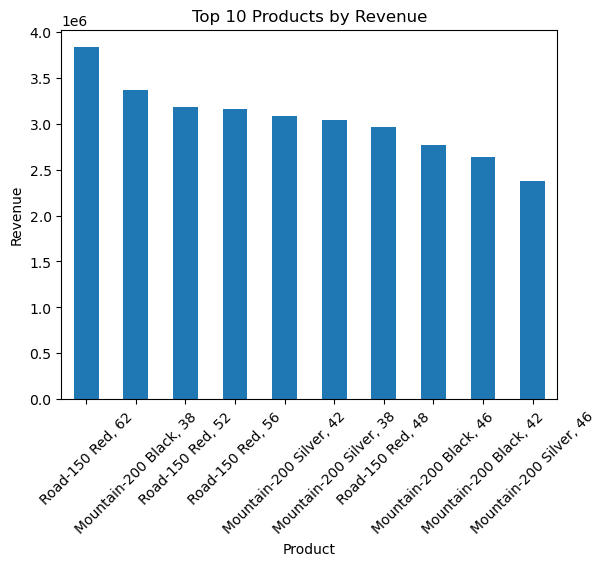

In [64]:
#Top 10 sản phẩm có doanh thu cao nhất
top_products = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(10)
plt.figure()
top_products.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

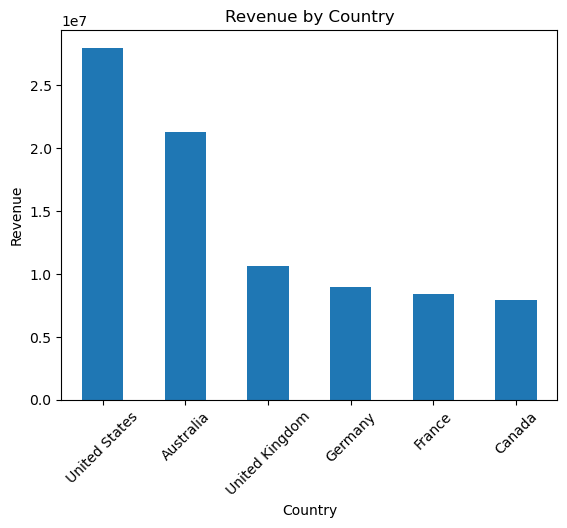

In [65]:
#Doanh thu theo quốc gia
revenue_country = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
plt.figure()
revenue_country.plot(kind='bar')
plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

<Figure size 640x480 with 0 Axes>

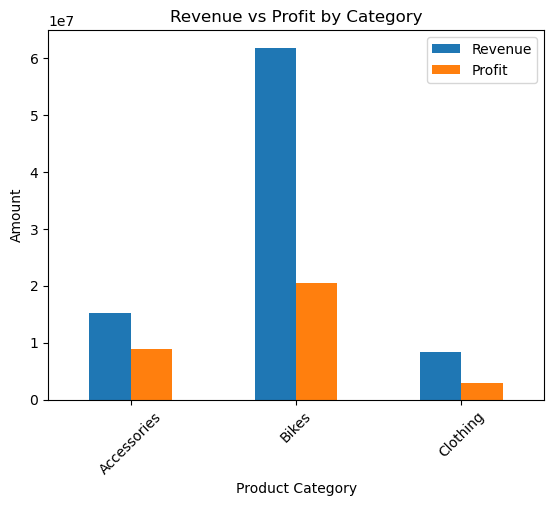

In [66]:
#so sánh Revenue và Profit theo Category
category = df.groupby('Product_Category')[['Revenue','Profit']].sum()
plt.figure()
category.plot(kind='bar')
plt.title("Revenue vs Profit by Category")
plt.xlabel("Product Category")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()